# PHYS 402 Lab Simulation
*F. Kelly, J. Seeberger, N. Shaffer*

---
## Part 1
In which we are instructed to write code which solves the Schrodinger equation, and finds eigenvalues and eigenfunctions for a harmonic oscillator with Hamiltonian:

$$
H_0 = \frac{p^2}{2m} + \frac{1}{2}m\omega^2x^2
$$

Assuming that 

$$
\hbar = \omega = m = 1
$$

Plot the solved eigenfunctions and the analytical functions in one plot done three times for $n=0$, $n=1$, and $n=2$ states, write down the plot the solved eigenenergy and the true eiegenenergy.

## Simplifying the equation

$$
H_0 = \frac{\hat{p}^2}{2m} + \frac{1}{2}m\omega^2 \hat{x}^2 = -\frac{1}{2}\frac{d^2}{d x^2} + \frac{1}{2}x^2
$$

Using approximation:

$$
\frac{d^2 f}{d x^2} \approx \frac{f(x_{n-1}) - 2f(x_n) + f(x_{n+1})}{\Delta x^2}
$$

------------------------
Numerical Eigenenergies: 0.4999988738702242 1.4999943693476483 2.4999853602783637
Analytical Eigenenergies: 0.4999988738702242 1.4999943693476483 2.4999853602783637
-----------------------


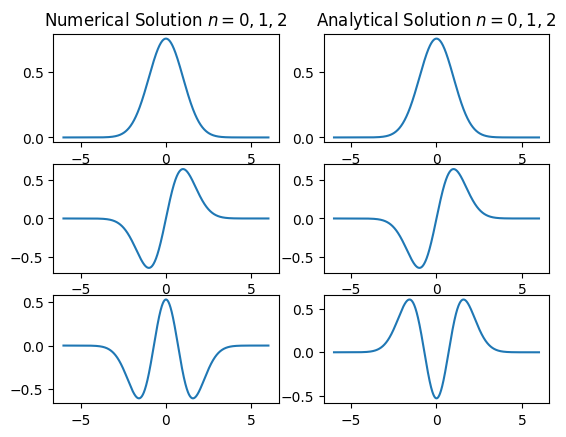

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.special import hermite
from math import factorial



def create_hamiltonian(x, V):
  """Return the hamiltonian for potential V on list x"""
  N = len(x)
  dx = x[1] - x[0]
  # Use approximate form of second derivative
  diag = np.ones(N) / (dx**2)
  off_diag = -0.5*np.ones(N-1) / (dx**2)
  T = np.diag(diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
  return T + np.diag(V)

def solve_schrodinger(x, V, n_states=3):
  """Diagonalize the hamiltonian and return the eigenvalues and eigenstates (eigenvalues, eigenstates)"""
  H = create_hamiltonian(x, V)
  vals, vecs = np.linalg.eigh(H)
  psis = []
  # For each eigenvalue, normalize the eigenstate and return both
  for n in range(n_states):
    psi = vecs[:, n]
    norm = np.trapezoid(psi**2, x)
    psis.append(psi / np.sqrt(norm))
  return vals[:n_states], psis

def analytical_psi(n, x):
  """Analytical solution of quantum harmonic oscillator"""
  Hn = hermite(n)
  norm = np.sqrt(2**n * factorial(n) * np.sqrt(np.pi))
  return Hn(x) * np.exp(-x**2 / 2) / norm

# PART 1 Numerical Solution
x = np.linspace(-6, 6, 2000)
V = 0.5 * x**2
E, psi = solve_schrodinger(x, V)

# PART 1 Analysical Solution
analytical = [analytical_psi(n, x) for n in range(3)]
true_E = [0.5, 1.5, 2.5] # since E = hbar * omega * (n + 1/2)

# PART 1 graph solutions
fig, axs = plt.subplots(3,2) # Create a 3row, 2column figure

axs[0,0].set_title("Numerical Solution $n=0,1,2$")
axs[0,1].set_title("Analytical Solution $n=0,1,2$")

for i in range(3):
    axs[i,0].plot(x,psi[i])           # plot the numerical solution
    axs[i,1].plot(x,analytical[i])    # plot the analytical solution

# PART 1 print eigenenergies
print("------------------------")
print("Numerical Eigenenergies:", E[0], E[1], E[2])
print("Analytical Eigenenergies:", E[0], E[1], E[2])
print("-----------------------")

## Part 2

Now in addition to the Hamiltonian above which we call $H_0$, add another term which is $\alpha x^3$, where $\alpha=0.2$. Repeat as in previous part except in this case only do the solved parameters since you don't have analytical ones.

$$
H_1 = \frac{p^2}{2m} + \frac{1}{2}m\omega^2x^2 + \alpha x^3, ~~~~ \hbar = \omega = m = 1
$$
$$
\implies H_1 = - \frac{1}{2} \frac{d^2}{dx^2} + \frac{1}{2} x^2 + 0.2 x^3
$$

------------------------
Numerical Eigenenergies: -14.640266229829743 -8.013844332370235 -3.594571335645264
Analytical Eigenenergies: -14.640266229829743 -8.013844332370235 -3.594571335645264
-----------------------


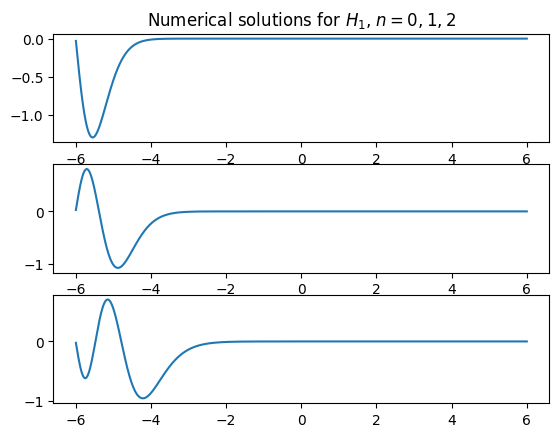

In [2]:
# PART 2
V = 0.5*x**2 + 0.2*x**3
E, psi = solve_schrodinger(x, V)

fig, axs = plt.subplots(3,1)

axs[0].set_title("Numerical solutions for $H_1$, $n=0,1,2$")

for i in range(3):
    axs[i].plot(x,psi[i])   # plot the numerical solution
    
# PART 1 print eigenenergies
print("------------------------")
print("Numerical Eigenenergies:", E[0], E[1], E[2])
print("Analytical Eigenenergies:", E[0], E[1], E[2])
print("-----------------------")